In [318]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import os
import glob

In [319]:
DATA_ROOT_PATH = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/data_v2"
POWER_MODES = ["HPM", "RPM", "LPM"]
FS_STR_LIST = ["500k", "1M", "2M", "3M", "4M", "5M", "6M"]

REF_HI = 2.8
REF_LO = 0.8

FS_LIST = [500e3, 1e6, 2e6, 3e6, 4e6, 5e6, 6e6]                                  # Fs
FI_LIST = [99.915e3, 99.976e3, 99.854e3, 99.976e3, 100.098e3, 99.487e3, 98.877e3]     # Fi
J_LIST = [1637, 819, 409, 273, 205, 163, 135]                                    # J
BUFFER_SIZE = 8192                                                          # M

hann_window = np.hanning(BUFFER_SIZE)

# SHUNT_VOLTAGE = {
#     "HPM": {"500k": 4.73e-3, "1M": 5.07e-3, "2M": 5.70e-3, "3M": 6.27e-3, "4M": 0.0, "5M": 7.54e-3},
#     "RPM": {"500k": 3.36e-3, "1M": 3.70e-3, "2M": 4.30e-3, "3M": 4.91e-3, "4M": 0.0, "5M": 6.15e-3},
#     "LPM": {"500k": 2.61e-3, "1M": 2.99e-3, "2M": 3.63e-3, "3M": 4.07e-3, "4M": 0.0, "5M": 4.57e-3}, # 5Mhz @ LMP is FAKE!! REMEMBER TO RETEST
# }

SHUNT_VOLTAGE = {
    "HPM": {"500k": 4.59e-3, "1M": 4.93e-3, "2M": 5.58e-3, "3M": 6.14e-3, "4M": 6.71e-3, "5M": 7.29e-3, "6M": 7.83e-3},
    "RPM": {"500k": 3.23e-3, "1M": 3.57e-3, "2M": 4.18e-3, "3M": 4.79e-3, "4M": 5.37e-3, "5M": 5.91e-3, "6M": 6.15e-3},
    "LPM": {"500k": 2.49e-3, "1M": 2.87e-3, "2M": 3.52e-3, "3M": 3.96e-3, "4M": 4.39e-3, "5M": 4.98e-3, "6M": 5.83e-3} # 5Mhz @ LMP is FAKE!! REMEMBER TO RETEST
}


SHUNT_RESISTANCE = 1.02 # ohms

#   Fs      |  Fclk_gen |       Fi
# 500kHz    |   8e6     |   99.915 kHz  x
# 1Mhz      |   16e6    |   99.976 kHz  x
# 2Mhz      |   32e6    |   99.854 kHz  x
# 3Mhz      |   48e6    |   99.976 kHz  x
# 4Mhz      |   64e6    |   100.098 kHz
# 5Mhz      |   80e6    |   99.487 kHz  x

In [320]:
# ── 1. Load raw data ──────────────────────────────────────────────────────────
raw_dfs = {pm: pd.DataFrame() for pm in POWER_MODES}

for power_mode_folder in os.listdir(DATA_ROOT_PATH):
    power_mode_folder_path = os.path.join(DATA_ROOT_PATH, power_mode_folder)
    if os.path.isdir(power_mode_folder_path) and power_mode_folder in POWER_MODES:
        for Fs_folder in os.listdir(power_mode_folder_path):
            Fs_path = os.path.join(power_mode_folder_path, Fs_folder)
            if os.path.isdir(Fs_path):
                for csv_file in glob.glob(os.path.join(Fs_path, "*.csv")):
                    df = pd.read_csv(csv_file)
                    # new format: columns are test_1, test_2, ... test_N
                    for k, col in enumerate(df.columns):
                        raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]

/tmp/ipykernel_1044335/2785987698.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


In [321]:
waveform_code = np.array(raw_dfs["HPM"]["1M0"].to_list())

signal = (waveform_code / 255) * (2.0) - 1.0

N = len(signal)

hanning_window = np.hanning(N)

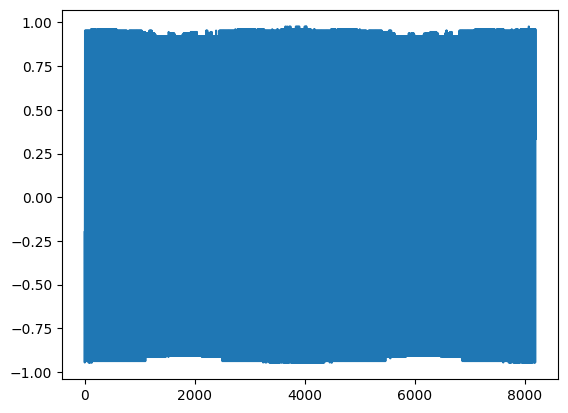

In [322]:
plt.plot(signal)

In [323]:
windowed_signal = signal * hann_window

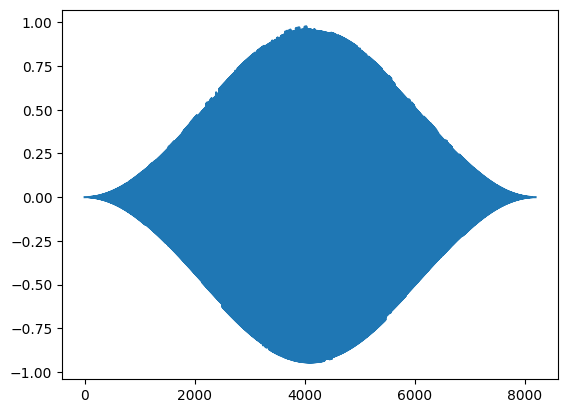

In [324]:
plt.plot(windowed_signal)

In [ ]:
Fs = 1e6

# ── Step 1: FFT ───────────────────────────────────────────────────────────────
fft_full = np.fft.fft(windowed_signal)       # complex G(k), length N
fft_mag  = np.abs(fft_full)                  # |G(k)| for peak finding

# ── Step 2: Find kmax (skip DC) ───────────────────────────────────────────────
fft_pos  = fft_mag[:N//2]
kmax     = np.argmax(fft_pos[1:]) + 1        # integer bin index

# ── Step 3: Pick the larger neighbor → compute r and fractional bin f ────────
# Equations (12)/(16) vs (17)/(18) — use whichever side bin is larger
if fft_mag[kmax - 1] > fft_mag[kmax + 1]:
    # left neighbor is bigger → use r = |G(kmax-1)| / |G(kmax)|  (Eq. 12)
    r  = fft_mag[kmax - 1] / fft_mag[kmax]
    fx = kmax + (1.0 - 2.0*r) / (1.0 + r)   # Eq. 16
else:
    # right neighbor is bigger → use r = |G(kmax+1)| / |G(kmax)|  (Eq. 17)
    r  = fft_mag[kmax + 1] / fft_mag[kmax]
    fx = kmax - (1.0 - 2.0*r) / (1.0 + r)   # Eq. 18

# ── Step 4: Estimated frequency ───────────────────────────────────────────────
f_resolution = Fs / N                        # Hz per bin
f_estimated  = fx * f_resolution

# ── Step 5: Amplitude and Phase (Equations 21 & 22) ──────────────────────────
# Note from Okawara p.9: numpy's fft does NOT divide by N, so we need /N here
dx   = fx - kmax
dy   = np.pi * dx
sinc = (dy / np.sin(dy)) if abs(dx) > 1e-10 else 1.0

A  = (-fft_mag[kmax] / N) * sinc * (dx - 1.0) * (dx + 1.0)   # Eq. 21
Po = (1 / (2*np.pi)) * np.angle(fft_full[kmax] * np.exp(-1j * dy))  # Eq. 22

print(f"kmax     = {kmax}")
print(f"fx       = {fx:.6f}  (fractional bin)")
print(f"f_est    = {f_estimated/1e3:.4f} kHz")
print(f"A        = {A:.6f} V")
print(f"Po       = {Po:.6f} rad")

kmax     = 819
fx       = 819.010993  (fractional bin)
f_est    = 9.9953 kHz
A        = 0.242334 V
Po       = 0.290426 rad


In [326]:
print(f"signal min: {signal.min():.3f}, max: {signal.max():.3f}")
print(f"signal peak: {(signal.max() - signal.min())/2:.3f} V")

signal min: -0.945, max: 0.976
signal peak: 0.961 V


In [327]:
coherent_gain = np.sum(hann_window) / N   # ≈ 0.5 for Hanning

dx   = fx - kmax
dy   = np.pi * dx
sinc = (dy / np.sin(dy)) if abs(dx) > 1e-10 else 1.0

A_raw       = (-fft_mag[kmax] / N) * sinc * (dx - 1.0) * (dx + 1.0)
A_corrected = A_raw / coherent_gain

print(f"A_raw       = {A_raw:.4f} V")
print(f"A_corrected = {A_corrected:.4f} V")   # expect ~0.96 V

coherent_gain = np.sum(hann_window) / N   # 0.5 for Hanning
A_corrected   = A_raw / coherent_gain * 2.0
print(f"A_corrected = {A_corrected:.4f} V")   # expect ~0.96 V

A_raw       = 0.2423 V
A_corrected = 0.4847 V
A_corrected = 0.9695 V


In [ ]:
Fs = 3e6
# ── FFT ───────────────────────────────────────────────────────────────────────
fft_full = np.fft.fft(windowed_signal)
fft_mag  = np.abs(fft_full)

# ── Find kmax ─────────────────────────────────────────────────────────────────
fft_pos = fft_mag[:N//2]
kmax    = np.argmax(fft_pos[1:]) + 1

# ── T&U interpolation ─────────────────────────────────────────────────────────
if fft_mag[kmax - 1] > fft_mag[kmax + 1]:
    r  = fft_mag[kmax - 1] / fft_mag[kmax]
    fx = kmax + (1.0 - 2.0*r) / (1.0 + r)
else:
    r  = fft_mag[kmax + 1] / fft_mag[kmax]
    fx = kmax - (1.0 - 2.0*r) / (1.0 + r)

# ── Amplitude, frequency, phase ───────────────────────────────────────────────
dx   = fx - kmax
dy   = np.pi * dx
sinc = (dy / np.sin(dy)) if abs(dx) > 1e-10 else 1.0
CG   = np.sum(hann_window) / N          # coherent gain ≈ 0.5

A  = (-fft_mag[kmax] / N) * sinc * (dx - 1.0) * (dx + 1.0) / CG * 2.0
f  = fx * (Fs / N)
Po = (1 / (2*np.pi)) * np.angle(fft_full[kmax] * np.exp(-1j * dy))

print(f"A  = {A:.4f} V")
print(f"f  = {f/1e3:.4f} kHz")
print(f"Po = {Po:.4f} rad")

A  = 0.9695 V
f  = 99.9769 kHz
Po = 0.2904 rad


In [329]:
# ── Reconstruct ideal sine in time domain ─────────────────────────────────────
t = np.arange(N) / Fs
ideal_signal = A * np.cos(2 * np.pi * f * t + 2 * np.pi * Po)

# ── Subtract ideal from original (no window — work in time domain) ────────────
noise = signal - ideal_signal

# ── RMS of signal and noise ───────────────────────────────────────────────────
rms_signal = np.sqrt(np.mean(ideal_signal**2))
rms_noise  = np.sqrt(np.mean(noise**2))

print(f"RMS signal = {rms_signal:.6f} V")
print(f"RMS noise  = {rms_noise:.6f} V")

RMS signal = 0.685503 V
RMS noise  = 0.036436 V


In [330]:
SINAD = 20 * np.log10(rms_signal / rms_noise)
ENOB  = (SINAD - 1.76) / 6.02

print(f"SINAD = {SINAD:.2f} dB")
print(f"ENOB  = {ENOB:.2f} bits")

SINAD = 25.49 dB
ENOB  = 3.94 bits


In [331]:
Fs = 1e6
fs_key = "1M"

# collect all column names for this Fs
test_cols = [col for col in raw_dfs["HPM"].columns if col.startswith(fs_key)]

signal_ffts = []
noise_ffts  = []

for col in test_cols:
    # ── Load and convert ──────────────────────────────────────────────────────
    waveform_code = np.array(raw_dfs["HPM"][col].to_list())
    signal = (waveform_code / 255) * 2.0 - 1.0
    N = len(signal)

    windowed_signal = signal * hann_window

    # ── FFT ───────────────────────────────────────────────────────────────────
    fft_full = np.fft.fft(windowed_signal)
    fft_mag  = np.abs(fft_full)

    # ── Find kmax ─────────────────────────────────────────────────────────────
    fft_pos = fft_mag[:N//2]
    kmax    = np.argmax(fft_pos[1:]) + 1

    # ── T&U interpolation ─────────────────────────────────────────────────────
    if fft_mag[kmax - 1] > fft_mag[kmax + 1]:
        r  = fft_mag[kmax - 1] / fft_mag[kmax]
        fx = kmax + (1.0 - 2.0*r) / (1.0 + r)
    else:
        r  = fft_mag[kmax + 1] / fft_mag[kmax]
        fx = kmax - (1.0 - 2.0*r) / (1.0 + r)

    # ── A, f, Po ──────────────────────────────────────────────────────────────
    dx   = fx - kmax
    dy   = np.pi * dx
    sinc = (dy / np.sin(dy)) if abs(dx) > 1e-10 else 1.0
    CG   = np.sum(hann_window) / N

    A  = (-fft_mag[kmax] / N) * sinc * (dx - 1.0) * (dx + 1.0) / CG * 2.0
    f  = fx * (Fs / N)
    Po = (1 / (2*np.pi)) * np.angle(fft_full[kmax] * np.exp(-1j * dy))

    # ── Reconstruct ideal and subtract ────────────────────────────────────────
    t            = np.arange(N) / Fs
    ideal_signal = A * np.cos(2 * np.pi * f * t + 2 * np.pi * Po)
    noise        = signal - ideal_signal

    # ── FFT of ideal and noise (unwindowed, power spectrum) ───────────────────
    signal_ffts.append(np.abs(np.fft.fft(ideal_signal)[:N//2])**2)
    noise_ffts.append(np.abs(np.fft.fft(noise)[:N//2])**2)

# ── Average across all tests ──────────────────────────────────────────────────
avg_signal_psd = np.mean(signal_ffts, axis=0)
avg_noise_psd  = np.mean(noise_ffts,  axis=0)

# ── RMS from averaged power spectra ──────────────────────────────────────────
rms_signal = np.sqrt(np.sum(avg_signal_psd)) / N
rms_noise  = np.sqrt(np.sum(avg_noise_psd))  / N

# ── SINAD and ENOB ────────────────────────────────────────────────────────────
SINAD = 20 * np.log10(rms_signal / rms_noise)
ENOB  = (SINAD - 1.76) / 6.02

print(f"Tests averaged : {len(test_cols)}")
print(f"RMS signal     = {rms_signal:.6f} V")
print(f"RMS noise      = {rms_noise:.6f} V")
print(f"SINAD          = {SINAD:.2f} dB")
print(f"ENOB           = {ENOB:.2f} bits")

Tests averaged : 100
RMS signal     = 0.484742 V
RMS noise      = 0.032502 V
SINAD          = 23.47 dB
ENOB           = 3.61 bits


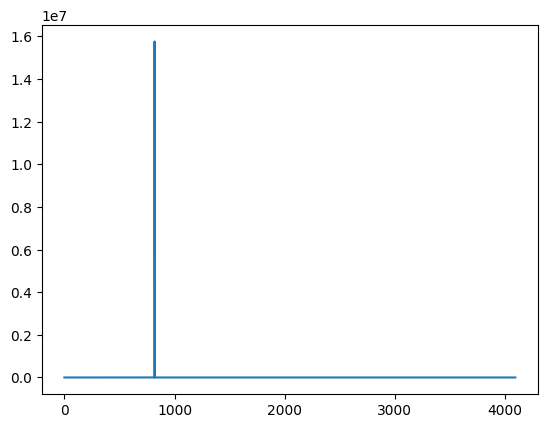

In [332]:
plt.plot(signal_ffts[0])

N tests available : 100
Unique code values : 186  (expect ~256 for good ADC)
Code min/max       : 7 / 252
A                  = 0.9695 V
f                  = 99.9769 kHz  (expect ~99.976 kHz)
noise peak-peak    = 0.3126 V
noise std          = 0.0237 V


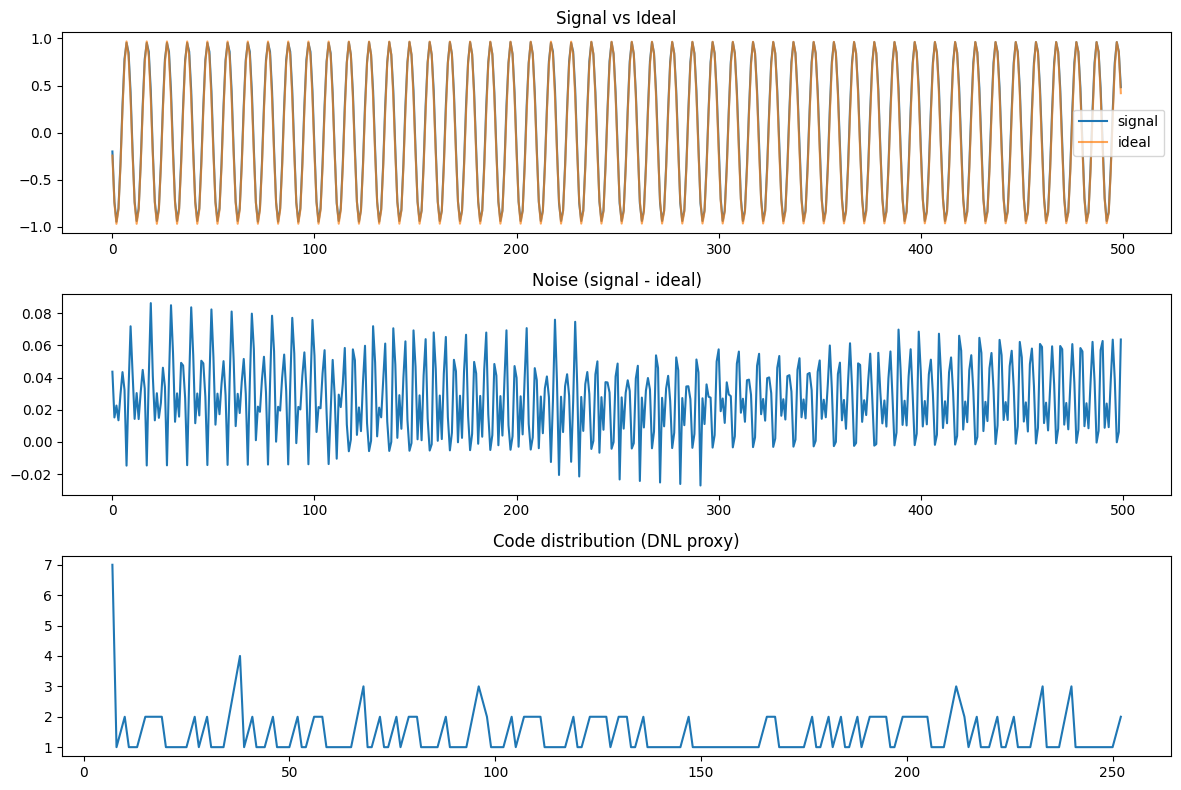

In [333]:
# ── Run on a single test first ────────────────────────────────────────────────
col = test_cols[0]
waveform_code = np.array(raw_dfs["HPM"][col].to_list())
signal = (waveform_code / 255) * 2.0 - 1.0
N = len(signal)
windowed_signal = signal * hann_window

fft_full = np.fft.fft(windowed_signal)
fft_mag  = np.abs(fft_full)
fft_pos  = fft_mag[:N//2]
kmax     = np.argmax(fft_pos[1:]) + 1

if fft_mag[kmax-1] > fft_mag[kmax+1]:
    r  = fft_mag[kmax-1] / fft_mag[kmax]
    fx = kmax + (1.0 - 2.0*r) / (1.0 + r)
else:
    r  = fft_mag[kmax+1] / fft_mag[kmax]
    fx = kmax - (1.0 - 2.0*r) / (1.0 + r)

dx   = fx - kmax
dy   = np.pi * dx
sinc = (dy / np.sin(dy)) if abs(dx) > 1e-10 else 1.0
CG   = np.sum(hann_window) / N

A  = (-fft_mag[kmax] / N) * sinc * (dx - 1.0) * (dx + 1.0) / CG * 2.0
f  = fx * (Fs / N)
Po = (1 / (2*np.pi)) * np.angle(fft_full[kmax] * np.exp(-1j * dy))

t            = np.arange(N) / Fs
ideal_signal = A * np.cos(2 * np.pi * f * t + 2 * np.pi * Po)
noise        = signal - ideal_signal

# ── Diagnostics ───────────────────────────────────────────────────────────────
print(f"N tests available : {len(test_cols)}")
print(f"Unique code values : {len(np.unique(waveform_code))}  (expect ~256 for good ADC)")
print(f"Code min/max       : {waveform_code.min()} / {waveform_code.max()}")
print(f"A                  = {A:.4f} V")
print(f"f                  = {f/1e3:.4f} kHz  (expect ~99.976 kHz)")
print(f"noise peak-peak    = {noise.max() - noise.min():.4f} V")
print(f"noise std          = {noise.std():.4f} V")

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(signal[:500],       label="signal")
axes[0].plot(ideal_signal[:500], label="ideal", alpha=0.7)
axes[0].legend(); axes[0].set_title("Signal vs Ideal")

axes[1].plot(noise[:500])
axes[1].set_title("Noise (signal - ideal)")

axes[2].plot(np.unique(waveform_code), np.diff(np.unique(waveform_code), prepend=0))
axes[2].set_title("Code distribution (DNL proxy)")

plt.tight_layout()
plt.show()

In [334]:
import math
effective_bits = math.log2(186)
print(f"Theoretical ENOB limit from missing codes: {effective_bits:.2f} bits")
# → ~7.5 bits theoretical, but DNL errors make it worse in practice

Theoretical ENOB limit from missing codes: 7.54 bits
